# EXPLORATORY DATA ANALYSIS (EDA)

# Student Loan Complaints: Exploratory Data Analysis & Text Classification

**Project Overview:**
This notebook analyzes consumer complaint data regarding student loans from the Consumer Financial Protection Bureau (CFPB). 

**Objectives:**
1. Perform Exploratory Data Analysis (EDA) to understand complaint trends, entities involved, and data distribution.
2. Clean and preprocess the dataset.
3. Prepare the data for a hierarchical Natural Language Processing (NLP) model to automatically tag the `Issue` and `Sub-issue` based on the consumer's text narrative.

## 1. Environment Setup
Importing the necessary libraries for data manipulation, statistical analysis, and data visualization.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as ss
import numpy as np

## 2. Data Loading & Initial Inspection
Loading the raw dataset and reviewing the schema, data types, and non-null counts to identify missing values early in the process.

In [ ]:
sld = pd.read_csv('../data/student_loan_complaints.csv')
sld.info()

**Initial Observations:**
* The dataset contains **~52,988 records** and **16 features**.
* The majority of the columns are categorical (`object` type).
* **Missing Data:** Our primary NLP feature, `Consumer complaint narrative`, contains significant missing data (only ~25,600 non-nulls). This will require filtering before model training. `Tags` and `Company public response` are also highly sparse.

## 3. Data Quality & Missing Values Assessment
Before diving into detailed analysis, it is crucial to assess the "health" of our dataset. We generate a summary table to evaluate data types, cardinality (unique values), and the percentage of missing data (nulls) across all features.

## Creating a DataFrame with an overview of all columns

In [ ]:
overview = pd.DataFrame({
    'Type': sld.dtypes,
    'Unique Values': sld.nunique(),
    'Nulls': sld.isnull().sum(),
    'Null Percentage (%)': (sld.isnull().sum() / len(sld)) * 100
})

print(overview.sort_values(by='Null Percentage (%)', ascending=False))

**Key Data Quality Insights:**
* **High Sparsity:** The `Tags` (90% null) and `Company public response` (74.6% null) columns are heavily missing data.
* **Target Feature Constraints:** Our primary input for the NLP model, `Consumer complaint narrative`, is missing in ~51.6% of the records. We will need to drop these empty rows later, as the text is mandatory for model training.
* **Zero Variance:** The `Product` column contains only 1 unique value ("Student loan"). Since it provides no variance, it holds no predictive power and can be safely dropped in later stages.

## 4. Feature Formatting: Datetime Conversion
The temporal features (`Date received` and `Date sent to company`) are currently stored as strings. To enable time-series analysis and allow us to extract meaningful temporal patterns (like months or years), we must convert them into proper Python datetime objects. 




## Converting date to datetime objects


In [ ]:
sld['Date received']=pd.to_datetime(sld['Date received'])
sld['Date sent to company']=pd.to_datetime(sld['Date sent to company'])

## 5. Feature Engineering: Temporal Extraction
To facilitate granular time-series analysis—such as observing monthly seasonality or annual complaint trends—we extract the specific 'Year' and 'Month' components from the `Date received` feature into dedicated columns.

## Adding new columns for easier time analysis (Year, Month)

In [ ]:
sld['Year received'] = sld['Date received'].dt.year
sld['Month received'] = sld['Date received'].dt.month

## 6. Data Integrity: Duplicate Verification
As a final step in our fundamental data cleaning process, we check for and remove any identical, duplicated records. Keeping duplicates could artificially inflate the importance of certain complaints and bias our predictive model.

## Check for duplicates


In [ ]:
print(f"Number of duplicated rows: {sld.duplicated().sum()}")
sld = sld.drop_duplicates()

## 7. Time-Series Exploration: Complaint Trends
Visualizing the volume of complaints over time helps us identify macro trends, seasonal patterns, or specific historical anomalies that triggered a surge in consumer dissatisfaction. We will examine the data from both a granular (monthly) and macro (yearly) perspective.

In [ ]:
import locale

try:
    locale.setlocale(locale.LC_TIME, 'en_US.UTF-8')
except locale.Error:
    pass

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

monthly_data = sld.set_index('Date received').resample('ME').size().iloc[:-1]
monthly_data.plot(ax=axes[0], color='blue')
axes[0].set_title('Number of Complaints Received Per Month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Number of Complaints')
axes[0].grid(True)

yearly_data = sld['Year received'].value_counts().sort_index()
yearly_data.plot(kind='bar', ax=axes[1], color='darkblue')
axes[1].set_title('Number of Complaints Received Per Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Complaints')
axes[1].set_axisbelow(True)
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

**Visual Insights & Trend Analysis:**
* **Macro Trend (Yearly):** There is a clear, aggressive upward trend in student loan complaints from 2023 to 2025. The total volume more than doubled during this period, peaking in 2025 .
* **Data Context (2026):** The sharp decline in 2026 is highly likely due to 2026 being an incomplete year in our current dataset, rather than a sudden resolution of student loan issues.
* **Volatility & Anomalies (Monthly):** The monthly line chart reveals extreme volatility. Most notably, there is a massive anomaly/spike around early 2025, where complaints surged to nearly 3,500 in a single month. In a real-world business scenario, this anomaly would warrant a targeted investigation (e.g., checking if it correlates with the resumption of federal loan payments, a policy change, or a system failure at a major loan servicer).

## 8. Entity Analysis: Top Complaint Targets
After observing the temporal trends, the next logical step is to identify which specific entities (Loan Servicers) are driving these complaint volumes. This horizontal bar chart highlights the top 10 most frequently reported organizations in our dataset.

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(y='Company', data=sld, order=sld['Company'].value_counts().iloc[:10].index, color='darkblue')
plt.title('Top 10 Student Loan Servicers by Number of Complaints')
plt.xlabel('Number of Complaints')
plt.ylabel('Student Loan Servicer')
plt.show()

**Key Entity Insights:**
* **Market Concentration:** The vast majority of complaints are heavily concentrated among a few key players. **MOHELA** is the absolute leader in consumer complaints (approaching 20,000), followed closely by **Nelnet, Inc.** * **Servicers vs. Lenders:** It is important to note that these top entities are primarily federal student loan *servicers* (contractors handling billing and customer service), rather than the original lenders. This suggests that the core of consumer frustration lies in the administration, customer support, and mechanical handling of the loans.

## 9. Target Variable Analysis: Issues & Sub-issues
As our ultimate objective is to build a hierarchical NLP classification model, we must thoroughly understand our target variables: `Issue` (Primary Target) and `Sub-issue` (Secondary Target). We begin by identifying the cardinality (number of unique classes) our model will need to predict.

## How many different Issues and Sub-issues are there?

In [ ]:
print(f"Number of Unique Issues: {sld['Issue'].nunique()}")
print(f"Number of Unique Sub-issues: {sld['Sub-issue'].nunique()}")

**Observation:**
The dataset contains **12 broad Issues** and **52 specific Sub-issues**. To understand the distribution of these classes, we will visualize the top 5 most frequent primary issues. Identifying class distributions early is critical, as it dictates how we will train our machine learning algorithms.

## Top 10 Most Common Issues

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(y='Issue', data=sld, order=sld['Issue'].value_counts().iloc[:5].index, color='darkblue')
plt.title('Top 5 Most Common Issues')
plt.xlabel('Number of Complaints')
plt.ylabel('Issue')
plt.show()

**Key Target Insights & Modeling Implications:**
* **Severe Class Imbalance:** The dataset is extremely skewed. The top category, *"Dealing with your lender or servicer"*, heavily dominates the data with over 30,000 complaints—more than three times the volume of the second most common issue.
* **Impact on NLP Model:** If we feed this data "as-is" into an NLP classifier, the model will likely develop a strong bias, predicting the majority class for almost every input to artificially achieve "high accuracy." 
* **Next Steps:** During the modeling phase, we must employ mitigation strategies to handle this imbalance, such as applying **Class Weights**, utilizing resampling techniques (like oversampling minority classes), and ensuring **Stratified Train/Test Splits**.

## 10. Hierarchical Structure: Issue to Sub-issue Mapping
Since our goal is to predict both the broad category (`Issue`) and the specific problem (`Sub-issue`), we must verify the parent-child relationship within our targets. Here, we examine the internal distribution of the dominant primary category to understand how its sub-classes are structured.

In [ ]:
print("\n--- Example: Sub-issues for the Most Common Issue ---")
top_issue = sld['Issue'].value_counts().index[0]
print(sld[sld['Issue'] == top_issue]['Sub-issue'].value_counts())

**Hierarchical Insights & Modeling Implications:**
* **Sub-class Distribution:** Even within the single largest parent category, the data is highly concentrated. Two specific sub-issues (*"Trouble with how payments are being handled"* and *"Received bad information about your loan"*) account for the vast majority of cases (over 11,000 each). 
* **Cascading Imbalance:** This proves that the class imbalance exists at multiple levels of our hierarchy. A hierarchical model will not only have to learn to accurately predict the dominant parent class but also differentiate between these two very similar, heavily weighted child classes without ignoring the minority ones (like *"Co-signer"*).

## 11. Operational Compliance: Timely Responses
Before finalizing our EDA on the tabular data, we briefly assess the operational efficiency of the loan servicers. This chart illustrates whether companies are meeting regulatory expectations by responding to consumer complaints within the required timeframe.

In [ ]:

plt.figure(figsize=(6, 4))
sns.countplot(x='Timely response?', data=sld, color='darkblue')
plt.title('Percentage of Timely Responses')
plt.xlabel('Timely Response')
plt.ylabel('Count')
plt.show()

**Operational Insights:**
* **Compliance Rate:** The vast majority of complaints (over 40,000) receive a timely response. However, a significant absolute volume (roughly 10,000 complaints) are delayed, indicating substantial operational bottlenecks within certain servicers.


## 12. Resolution Analysis: How Companies Respond
To conclude our exploration of the categorical metadata, we examine the final resolutions provided by the loan servicers. This visualizes the typical outcome for a consumer after a formal complaint is filed and processed.

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(y='Company response to consumer', data=sld, order=sld['Company response to consumer'].value_counts().index, color='darkblue')
plt.title('Company Response to Consumer')
plt.xlabel('Number of Complaints')
plt.ylabel('Response Type')
plt.show()

**Resolution Insights & Business Context:**
* **Standardized Outcomes:** The overwhelming majority of complaints are simply "Closed with explanation." This implies that servicers typically resolve disputes by providing clarifying information rather than changing the loan terms or admitting fault.
* **Lack of Financial Remedies:** Very few cases result in "monetary relief," highlighting that consumers rarely secure financial compensation or balance adjustments through this specific complaint channel.
* **Data Leakage Warning:** While insightful for business intelligence, "Company response" is a *post-facto* variable (it occurs after the complaint is fully processed). We absolutely cannot use this as an input feature to predict the `Issue`, as doing so would cause severe data leakage in our predictive model.

## 13. Geographic Distribution: Complaints by State
To understand the regional footprint of student loan grievances, we visualize the volume of complaints across the United States. This interactive choropleth map helps identify areas with the highest absolute concentration of affected consumers.

In [ ]:
import plotly.express as px


state_counts = sld['State'].value_counts().reset_index()
state_counts.columns = ['State', 'Number of Complaints']


fig = px.choropleth(
    state_counts,
    locations='State',                  
    locationmode="USA-states",           
    color='Number of Complaints',       
    scope="usa",                         
    color_continuous_scale="Blues",       
    title="Distribution of Complaints by State (USA)",
    labels={'Number of Complaints': 'Number of Complaints'}
)

fig.show()

**Geographic Insights & Limitations:**
* **Population Bias:** The states highlighted in the deepest blue (indicating the highest complaint volumes) are California, Texas, Florida, and New York. This distribution heavily mirrors the general US population density. Therefore, high volumes here are a function of population size rather than inherently worse lending practices in these specific regions.


# Natural Language Processing (NLP) Preparation

## 14. Text Analysis: Narrative Length Distribution
As we have established that the `Consumer complaint narrative` is our sole predictive feature, our focus shifts entirely to textual analysis. The first step in any NLP pipeline is understanding the length and structure of the documents. We drop all rows with missing narratives and calculate the word count for each complaint.

In [ ]:
df_text = sld.dropna(subset=['Consumer complaint narrative']).copy()

df_text['Word Count'] = df_text['Consumer complaint narrative'].apply(lambda x: len(str(x).split()))

print("\n--- Statistics of Text Lengths (in words) ---")
print(df_text['Word Count'].describe())


**Statistical Breakdown:**
* **Dataset Size:** After removing nulls, we are left with exactly **25,603** viable text samples for training.
* **Averages:** The average (mean) complaint is approximately 220 words, with a median of 165 words, indicating a right-skewed distribution.
* **Extremes:** The shortest text is just 4 words (which might lack sufficient context for accurate classification), while the longest is a massive 4,994 words. 

Next, we visualize this distribution (capping the view at 1,000 words to filter out extreme outliers).

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df_text[df_text['Word Count'] < 1000]['Word Count'], bins=50, color='darkblue')
plt.title('Distribution of Word Counts in Consumer Complaints (< 1000 words)')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

**NLP Modeling Implications:**
* **Right-Skewed Distribution:** The histogram confirms that the vast majority of complaints fall within the 50 to 300-word range. 


### Categorical Correlation Analysis (Cramer's V)
In this step, we evaluate whether our available metadata (e.g., `Company`, `State`, `Submitted via`) have any statistical relationship with our targets: the hierarchical prediction of the `Issue` and, consequently, the `Sub-issue`. Since we are dealing with categorical data, we use the **Cramer's V** statistic (ranging from 0 = no correlation, to 1 = perfect association).

**Key Findings:**
* As the heatmap shows, the only strong correlation (0.95) is between `Issue` and `Sub-issue`, which is expected since one category is a hierarchical subset of the other.
* The remaining complaint metadata (Company, State, etc.) exhibit **near-zero predictive power** for both targets (scores < 0.25).
* This statistically proves that including these columns in our model would primarily introduce noise. 
* We conclude that the issue classification (tagging) must rely exclusively on analyzing the free-text (`Consumer complaint narrative`).

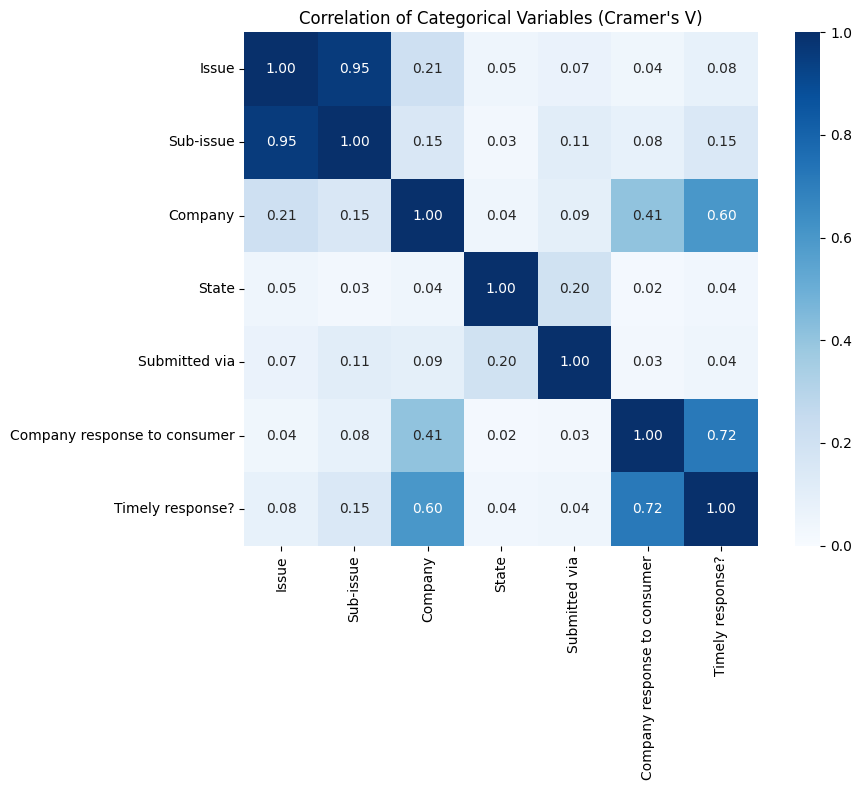

In [49]:

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    
    
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    
   
    denominator = min((kcorr-1), (rcorr-1))
    if denominator == 0:
        return 0.0
    return np.sqrt(phi2corr / denominator)

categorical_cols = [
    'Issue', 'Sub-issue', 'Company', 'State', 
    'Submitted via', 'Company response to consumer', 'Timely response?'
]

df_temp = sld[categorical_cols].fillna('Unknown')

cramers_matrix = pd.DataFrame(index=categorical_cols, columns=categorical_cols)


for col1 in categorical_cols:
    for col2 in categorical_cols:
        cramers_matrix.loc[col1, col2] = cramers_v(df_temp[col1], df_temp[col2])


cramers_matrix = cramers_matrix.astype(float)

plt.figure(figsize=(10, 8))
sns.heatmap(cramers_matrix, annot=True, fmt=".2f", cmap="Blues", vmin=0, vmax=1, square=True)
plt.title("Correlation of Categorical Variables (Cramer's V)")
plt.tight_layout()
plt.show()

## Final Data Pruning & Export

The conclusive results of our Cramer's V analysis confirm that the categorical metadata offers no predictive value for our target variables. To prevent noise and eliminate the risk of data leakage, we will discard these columns entirely. 

In this final step of our exploratory phase, we isolate the essential NLP features (`Consumer complaint narrative`, `Issue`, and `Sub-issue`), remove any records missing the text narrative, and export the cleaned dataset for the next phase of our pipeline.

In [ ]:

nlp_columns = ['Consumer complaint narrative', 'Issue', 'Sub-issue']
df_clean = sld[nlp_columns].copy()

df_clean = df_clean.dropna(subset=['Consumer complaint narrative'])

df_clean.to_csv('../data/student_loan_nlp_clean.csv', index=False)
print(f"Final clean dataset created with {df_clean.shape[0]} rows and {df_clean.shape[1]} columns.")

**Conclusion of Data Preparation:**
The dataset has been successfully streamlined. We now possess a highly focused, clean dataset containing exactly what our machine learning model needs: the textual input and the hierarchical targets. This officially concludes the Exploratory Data Analysis (EDA) phase. The exported file is now perfectly formatted and ready to be ingested by our Natural Language Processing (NLP) algorithms. 